# 03 - First experiment: learn when to break the planned order after a malfunction

**Hypothesis.** The OR reference keeps every cell's visiting order fixed (ordered execution, MCP).
That makes it deadlock-free, but one broken train then holds up every train planned behind it,
even when a waiting train could safely go first. A small learned gate that decides, per blocked
train, "keep the order" or "overtake and re-plan", should recover part of the arrivals and delay
the OR reference loses under malfunctions, at a cost of milliseconds per decision.

**Why RL, not more OR.** The decision is local and frequent, its consequences arrive tens of
steps later, and the simulator is deterministic and cloneable, so every decision can be scored
counterfactually. That is the setting where a learned policy can beat a fixed rule and a full
re-plan is too slow at scale.

**Plan.**
1. *(working)* Measure knock-on delay in the OR reference: which trains wait, on whom, and for how long.
2. *(TODO)* Re-plan one train from its current position so it can overtake safely.
3. *(TODO)* Train a gate {keep, overtake} with counterfactual rewards from cloned environments.
4. *(TODO)* Evaluate against the OR reference on the held-out malfunction seeds of all scenarios.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from collections import defaultdict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from flatland.envs.step_utils.states import TrainState
from rl_flatland.scenarios import make_env, TEST_MALFUNCTION_SEEDS
from rl_flatland.baselines.or_planner import PrioritizedPlannerPolicy
from rl_flatland.graph import STOP_MOVING

## 1. Measure knock-on delay in the OR reference

For every step, record each train that the executor holds (`STOP_MOVING` at a cell exit, or not
departing although its planned time has come). For each, find the train it waits for (the head of
the visit list of its next cell) and whether that train is broken down right now.

In [2]:
def instrumented_run(scenario="large", seed=TEST_MALFUNCTION_SEEDS[0]):
    env = make_env(scenario, seed, malfunctions=True)
    pol = PrioritizedPlannerPolicy()
    pol.reset(env)
    planned_arrival = {h: p[-1][1] for h, p in pol.paths.items()}
    waits = []
    done = {"__all__": False}
    while not done["__all__"]:
        acts = pol.act(env)
        t = env._elapsed_steps
        for h, p in pol.paths.items():
            a = env.agents[h]
            nxt = pol.progress[h] + 1
            if a.state == TrainState.DONE or nxt >= len(p) or a.malfunction_handler.in_malfunction:
                continue
            held = (a.state.is_on_map_state() and acts.get(h) == STOP_MOVING
                    and a.speed_counter.is_cell_exit(a.speed_counter.max_speed))
            held |= (a.state.is_off_map_state() and t + 1 >= p[nxt][1] and t >= a.earliest_departure and acts.get(h) == 0)
            if not held:
                continue
            cell = p[nxt][0][:2]
            ptr = pol._head(cell)
            lst = pol.visits[cell]
            blocker = lst[ptr][1] if ptr < len(lst) and lst[ptr][1] != h else None
            broken = blocker is not None and env.agents[blocker].malfunction_handler.in_malfunction
            if t + 1 < p[nxt][1]:
                reason = "planned wait"          # the plan itself holds the train here
            elif broken:
                reason = "blocker broken"        # next cell's earlier visitor is broken down
            else:
                reason = "blocker late"          # earlier visitor is late for other reasons (knock-on)
            waits.append(dict(t=t, train=h, blocker=blocker, cell=cell, reason=reason))
        _, _, done, _ = env.step(acts)
        pol.observe(env)
    rows = []
    for h, pa in planned_arrival.items():
        a = env.agents[h]
        rows.append(dict(train=h, planned_arrival=pa, arrival=a.arrival_time, LA=a.latest_arrival,
                         own_malfunctions=a.malfunction_handler.num_malfunctions))
    return env, pol, pd.DataFrame(waits), pd.DataFrame(rows)

env, pol, waits, trains = instrumented_run()
trains["delay"] = trains.arrival - trains.planned_arrival
n = env.get_num_agents()
print(f"{len(pol.paths)}/{n} trains routed; arrived {trains.arrival.notna().sum()}; "
      f"{env.agents and sum(a.malfunction_handler.num_malfunctions for a in env.agents)} malfunctions")
print("held train-steps by cause:", waits.reason.value_counts().to_dict() if len(waits) else {})
trains.sort_values("delay", ascending=False).head(10)

60/60 trains routed; arrived 58; 85 malfunctions
held train-steps by cause: {'blocker late': 4036, 'planned wait': 742, 'blocker broken': 313}


,train,planned_arrival,arrival,LA,own_malfunctions,delay
50,36,977,1134.0,1071,2,157.0
39,17,990,1131.0,869,4,141.0
24,8,895,1019.0,1063,2,124.0
32,31,912,1028.0,973,0,116.0
54,3,1084,1200.0,1126,1,116.0
49,54,990,1106.0,1007,1,116.0
47,58,941,1057.0,994,1,116.0
45,6,940,1056.0,971,2,116.0
37,59,887,992.0,838,3,105.0
33,30,910,1005.0,981,0,95.0


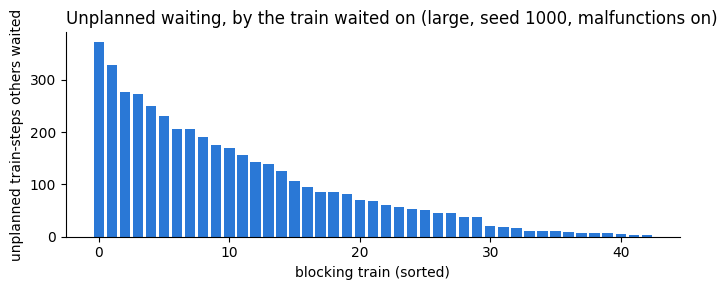

In [3]:
if len(waits):
    per_blocker = waits[waits.reason != "planned wait"].groupby("blocker").size().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(range(len(per_blocker)), per_blocker.values, color="#2a78d6")
    ax.set_xlabel("blocking train (sorted)"); ax.set_ylabel("unplanned train-steps others waited")
    ax.set_title("Unplanned waiting, by the train waited on (large, seed 1000, malfunctions on)", loc="left")
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
    plt.tight_layout()

**Read the numbers before going on.** "Planned wait" steps are holds the plan itself contains; no
execution rule can remove them, only a better plan. "Blocker broken" and "blocker late" are the
knock-on delay that ordered execution adds after malfunctions, and that is the budget an overtaking
gate competes for. If it is small relative to the arrivals lost, target re-planning instead. Repeat over all 10 malfunction seeds of `large` and `xlarge` before deciding (TODO 0).

In [4]:
# TODO 0: loop instrumented_run over TEST_MALFUNCTION_SEEDS for "large" and "xlarge" and report
#   - total knock-on delay (sum of positive `delay` for trains with own_malfunctions == 0)
#   - share of held train-steps whose blocker is broken
#   - arrivals lost relative to the no-malfunction seeds (see data/results/or.json)


## 2. TODO: re-plan one train from where it stands

To let train B overtake a delayed train A at a cell, B needs a new timed path from its *current*
configuration that avoids the reservations of every other train, and A's remaining visits must be
moved behind B's. `or_planner.sipp` plans from an off-map start. Extend it:

* start state = B's current configuration, entered at `now - (steps already spent in the cell)`;
* remove B's old reservations from `pol.rt` (keep a per-train list of reserved intervals so they
  can be deleted) and B's old entries from `pol.visits`;
* reserve A's current cell until `now + remaining malfunction + k_A`, so B's new path avoids it;
* insert B's new visits and shift A's remaining visits after B's in every shared cell.

Check with the deadlock detector and `pol.deviations` that execution stays deadlock-free.

In [5]:
def replan_train(pol, env, h, now):
    """TODO: return a new path for train h starting at its current configuration, or None."""
    raise NotImplementedError

## 3. TODO: the learned gate

Decision point: a train is held by the order rule while its blocker is broken or more than `d`
steps behind plan. Features (all available now): blocker's remaining malfunction steps, blocker's
delay, held train's slack `LA - t - k * remaining distance`, number of trains queued behind the held
train, length of the shared stretch. Action: keep (0) or overtake-and-replan (1).

Reward, counterfactually: the simulator is deterministic between malfunctions, so clone the env
(`RailEnv.clone_from`) and roll out both choices for a fixed window (say 100 steps) under the OR
executor. Reward = reduction in summed lateness plus 10 × extra arrivals. That gives a contextual
bandit, not a long-horizon RL problem, and a 2-layer MLP or even logistic regression should do.

In [6]:
# TODO 3a: collect (features, reward_keep, reward_overtake) tuples on training seeds (0..999, malfunctions on)
# TODO 3b: fit a classifier / bandit policy; report its regret against the counterfactual oracle


## 4. TODO: evaluate

Wrap the gate in a `Policy` subclass of `PrioritizedPlannerPolicy` and run
`python scripts/evaluate.py`-style evaluation (see `rl_flatland.evaluation.evaluate`) on the
held-out malfunction seeds of all four scenarios. Report arrival rate, normalised reward,
deadlocks (must stay 0) and ms per decision, next to the stored OR reference numbers in
`data/results/or.json`. The paper-sized claim is: "a learned overtaking gate recovers X% of the
arrivals the order-preserving planner loses under malfunctions, at Y ms per decision".